# basic

In [1]:
%load_ext autoreload
%autoreload all

In [2]:
import polars as pl
import numpy as np
import pickle
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import src.configs as configs
 

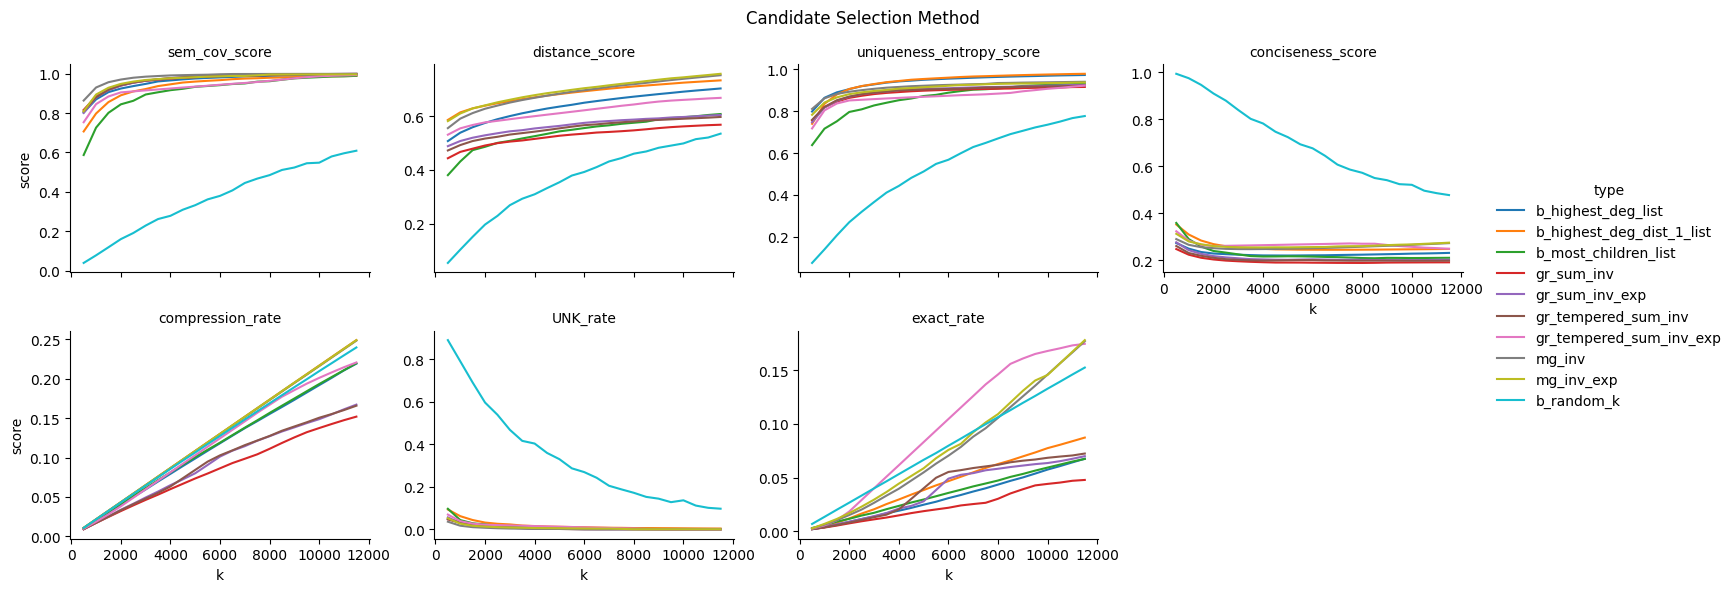

In [3]:
df_performance = pl.read_parquet(f"{configs.Results().path}scores.parquet")

metrics = [
    "sem_cov_score",
    "distance_score",
    "uniqueness_entropy_score",
    "conciseness_score",
    "compression_rate",
    "UNK_rate",
    "exact_rate",
]

df_long = (
    df_performance
    .unpivot(on=metrics, index=["method", "k"], variable_name="variable", value_name="score")
    .rename({"method": "type"})
    .to_pandas()
)

g = sns.relplot(
    data=df_long,
    x="k",
    y="score",
    hue="type",
    col="variable",
    col_wrap=4,
    kind="line",
    # marker="o",
    facet_kws={"sharey": False},
    height=3,
    aspect=1.25,
)
g.set_titles("{col_name}")
g.set_axis_labels("k", "score")

g.fig.suptitle("Candidate Selection Method")
g.tight_layout()

plt.show()


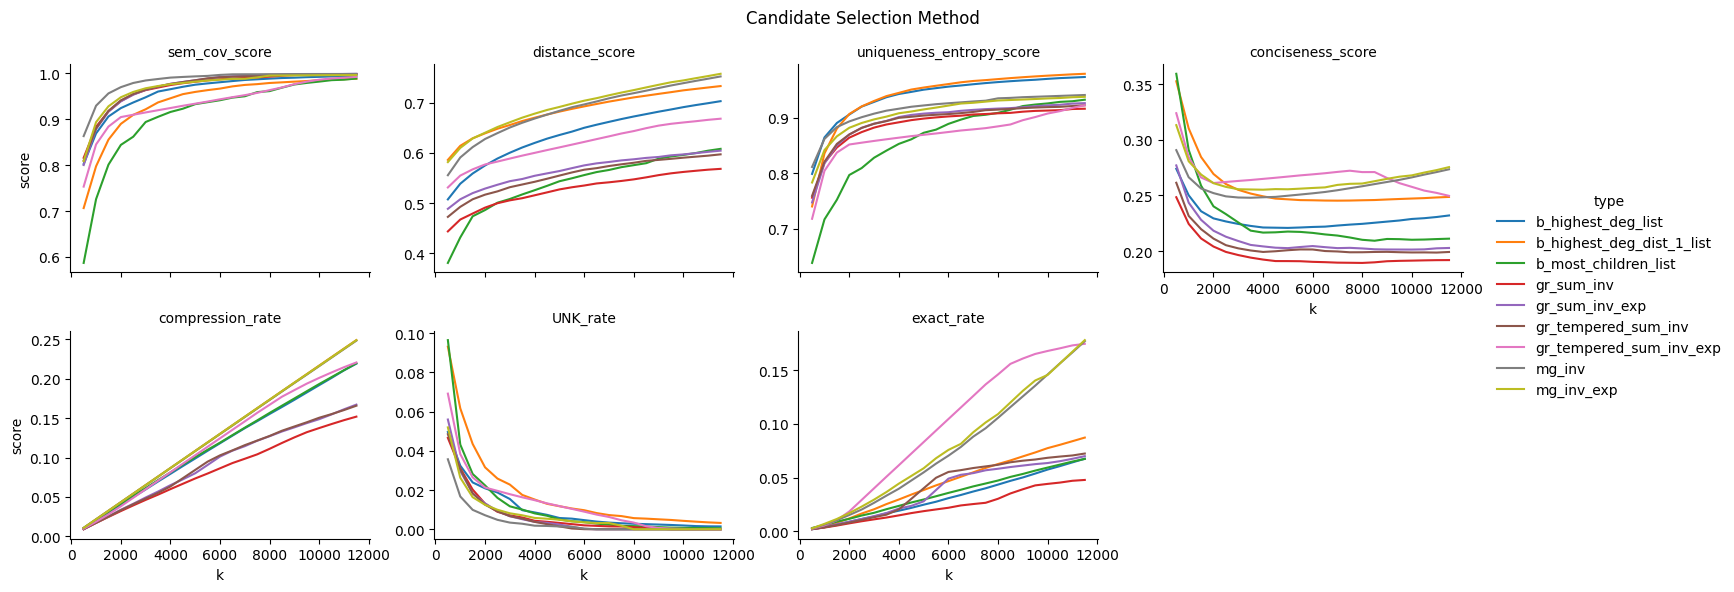

In [4]:
df_performance_elit = pl.read_parquet(f"{configs.Results().path}scores.parquet").filter(pl.col("method") != "b_random_k")
metrics = [
    "sem_cov_score",
    "distance_score",
    "uniqueness_entropy_score",
    "conciseness_score",
    "compression_rate",
    "UNK_rate",
    "exact_rate",
]

df_long = (
    df_performance_elit
    .unpivot(on=metrics, index=["method", "k"], variable_name="variable", value_name="score")
    .rename({"method": "type"})
    .to_pandas()
)

g = sns.relplot(
    data=df_long,
    x="k",
    y="score",
    hue="type",
    col="variable",
    col_wrap=4,
    kind="line",
    # marker="o",
    facet_kws={"sharey": False},
    height=3,
    aspect=1.25,
)
g.set_titles("{col_name}")
g.set_axis_labels("k", "score")

g.fig.suptitle("Candidate Selection Method")
g.tight_layout()

plt.show()


# elbow? convex?

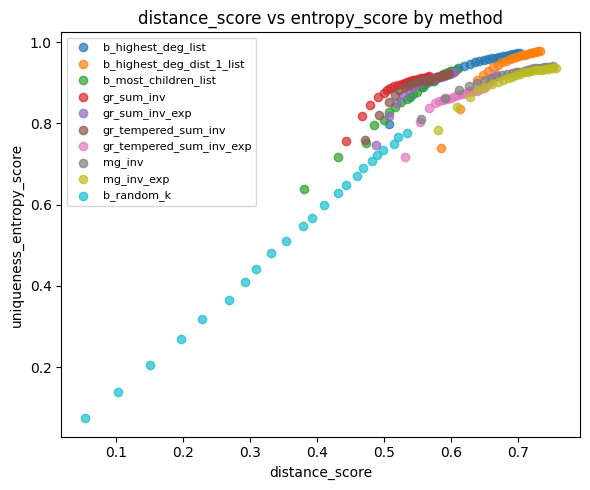

In [11]:
import matplotlib.pyplot as plt

df_plot = df_performance.to_pandas()

methods = df_plot["method"].unique()
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(6, 5))

for i, method in enumerate(methods):
    sub = df_plot[df_plot["method"] == method]
    ax.scatter(sub["distance_score"], sub["uniqueness_entropy_score"],
               color=colors[i % len(colors)], label=method, alpha=0.7)

ax.set_xlabel("distance_score")
ax.set_ylabel("uniqueness_entropy_score")
ax.legend(fontsize=8)
ax.set_title("distance_score vs entropy_score by method")
fig.tight_layout()
plt.show()

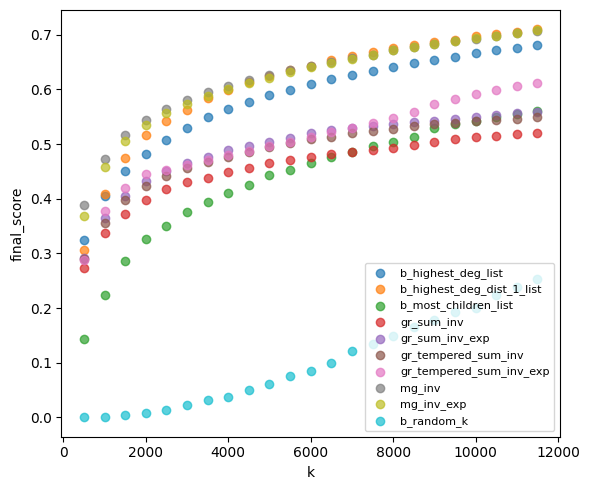

In [19]:
df_performance_new = (df_performance
                      .with_columns(final_score = pl.col("distance_score") * pl.col("uniqueness_entropy_score") * pl.col("sem_cov_score"))
                      .to_pandas())
fig, ax = plt.subplots(figsize=(6, 5))

for i, method in enumerate(methods):
    sub = df_performance_new[df_performance_new["method"] == method]
    ax.scatter(sub["k"], sub["final_score"],
               color=colors[i % len(colors)], label=method, alpha=0.7)

ax.set_xlabel("k")
ax.set_ylabel("final_score")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [ ]:
metrics = [
    "sem_cov_score",
    "distance_score",
    "uniqueness_entropy_score",
    "conciseness_score",
    "compression_rate",
    "UNK_rate",
    "exact_rate",
]

df_pd = df_performance.to_pandas()
k_values = sorted(df_pd["k"].unique())

ncols = 3
nrows = -(-len(k_values) // ncols)  # ceil division

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
axes = axes.flatten()

for i, k_val in enumerate(k_values):
    corr = df_pd[df_pd["k"] == k_val][metrics].corr()
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        ax=axes[i],
        cbar=i == 0,
    )
    axes[i].set_title(f"k = {k_val}")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Metric Correlation Matrix by k", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()
